In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nTarget values:")
print(y.value_counts())

X.head()

Dataset shape: (569, 30)

Target values:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Target names:", data.target_names)
print("\nTarget distribution:")
print(y.value_counts())

Target names: ['malignant' 'benign']

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [6]:
model = LogisticRegression(random_state=42, max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [7]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [8]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predicted probabilities:")
print(y_prob[:10])

Predicted probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


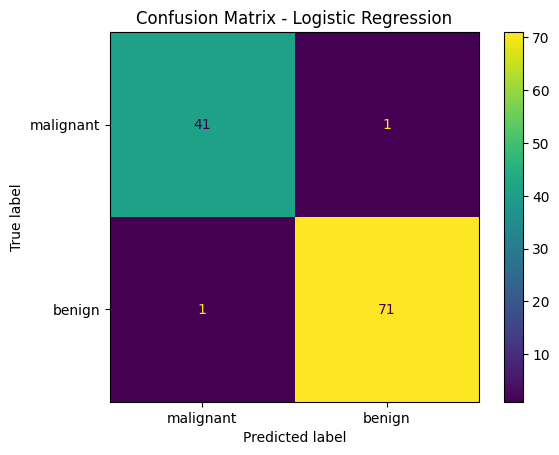

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [12]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9861111111111112
Recall: 0.9861111111111112


In [13]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9953703703703703


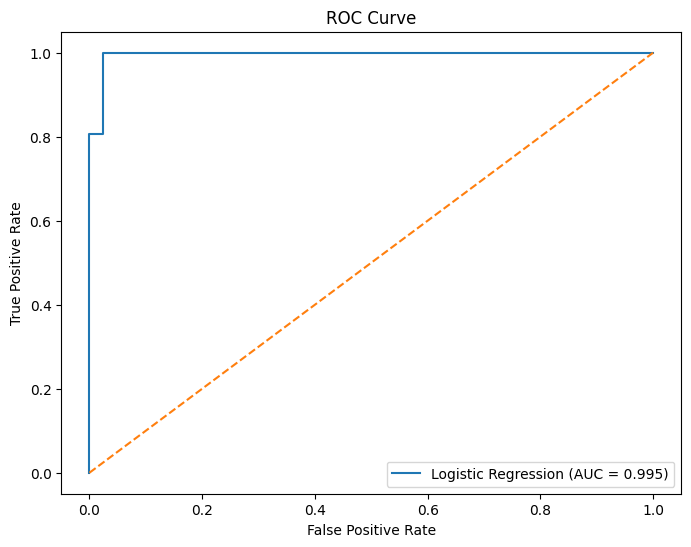

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

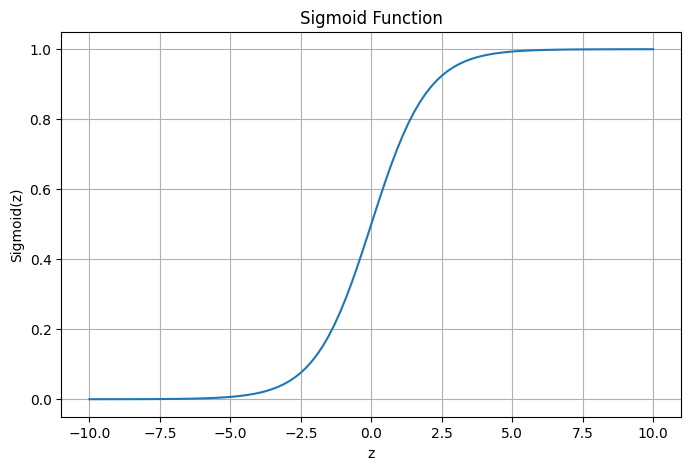

In [15]:
z = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid)

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

In [16]:
threshold = 0.3

y_pred_threshold = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [17]:
precision_new = precision_score(y_test, y_pred_threshold)
recall_new = recall_score(y_test, y_pred_threshold)

print("Threshold:", threshold)
print("Precision:", precision_new)
print("Recall:", recall_new)

Threshold: 0.3
Precision: 0.972972972972973
Recall: 1.0


In [18]:
thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.2 | Precision: 0.973 | Recall: 1.000
Threshold: 0.3 | Precision: 0.973 | Recall: 1.000
Threshold: 0.4 | Precision: 0.986 | Recall: 0.986
Threshold: 0.5 | Precision: 0.986 | Recall: 0.986
Threshold: 0.6 | Precision: 0.986 | Recall: 0.944
Threshold: 0.7 | Precision: 0.985 | Recall: 0.931
Threshold: 0.8 | Precision: 0.985 | Recall: 0.917


## Conclusion

In this task, a Logistic Regression model was developed for binary classification using the Breast Cancer Wisconsin dataset. The dataset was divided into training and testing sets, and the features were standardized before model training.

The model was evaluated using a confusion matrix, precision, recall, and ROC-AUC. The ROC curve was also plotted to understand the classification performance. The sigmoid function was visualized to understand how Logistic Regression converts model outputs into probabilities.

Different classification thresholds were tested to understand the trade-off between precision and recall.